# CampusFlow  — Modèle ML de prédiction de congestion
**Objectif :** Prédire le niveau de congestion (faible / moyen / élevé) d'une salle à partir de features contextuelles.

Pipeline :
1. Chargement & exploration
2. Nettoyage
3. Feature engineering
4. Entraînement
5. Évaluation
6. Export model.pkl

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

print('Imports OK')

Imports OK


## 2. Chargement du dataset

In [2]:
df = pd.read_csv('../data/raw/flux historique.csv')
print(f'Shape : {df.shape}')
df.head(10)

Shape : (5100, 7)


,location_id,timestamp,heure_du_jour,jour_semaine,activite_prevue,nombre_etudiants,niveau_congestion
0,1,2026-05-01 07:00:00,7,4,1,102,eleve
1,2,2026-05-01 07:00:00,7,4,0,5,faible
2,3,2026-05-01 07:00:00,7,4,0,18,moyen
3,4,2026-05-01 07:00:00,7,4,0,8,faible
4,5,2026-05-01 07:00:00,7,4,0,9,faible
5,6,2026-05-01 07:00:00,7,4,1,50,eleve
6,7,2026-05-01 07:00:00,7,4,0,4,faible
7,8,2026-05-01 07:00:00,7,4,0,4,faible
8,9,2026-05-01 07:00:00,7,4,0,0,faible
9,10,2026-05-01 07:00:00,7,4,0,0,faible


In [3]:
# Types et valeurs manquantes
print(df.dtypes)
print('\nValeurs nulles :')
print(df.isnull().sum())

location_id           int64
timestamp            object
heure_du_jour         int64
jour_semaine          int64
activite_prevue       int64
nombre_etudiants      int64
niveau_congestion    object
dtype: object

Valeurs nulles :
location_id          0
timestamp            0
heure_du_jour        0
jour_semaine         0
activite_prevue      0
nombre_etudiants     0
niveau_congestion    0
dtype: int64


In [4]:
# Distribution de la variable cible
print('Distribution niveau_congestion :')
print(df['niveau_congestion'].value_counts())
print('\nValeurs uniques location_id :', sorted(df['location_id'].unique()))

Distribution niveau_congestion :
niveau_congestion
faible    2407
moyen     1640
eleve     1053
Name: count, dtype: int64

Valeurs uniques location_id : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


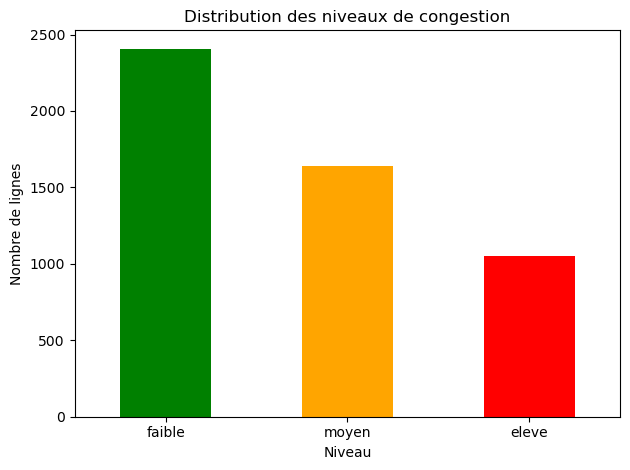

In [5]:
# Visualisation distribution cible
df['niveau_congestion'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('Distribution des niveaux de congestion')
plt.xlabel('Niveau')
plt.ylabel('Nombre de lignes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Nettoyage

In [6]:
# Supprimer les nulls
df.dropna(inplace=True)

# Vérifier les valeurs de niveau_congestion
valeurs_valides = ['faible', 'moyen', 'eleve']
invalides = df[~df['niveau_congestion'].isin(valeurs_valides)]
print(f'Lignes invalides : {len(invalides)}')
df = df[df['niveau_congestion'].isin(valeurs_valides)]

# Convertir timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f'Shape après nettoyage : {df.shape}')

Lignes invalides : 0
Shape après nettoyage : (5100, 7)


## 4. Feature Engineering

In [7]:
# Merger avec campus.json pour récupérer la capacité
with open('../data/raw/campus.json', 'r') as f:
    campus = json.load(f)

campus_df = pd.DataFrame(campus)
print('Colonnes campus.json :', campus_df.columns.tolist())
campus_df.head()

Colonnes campus.json : ['id', 'nom', 'latitude', 'longitude', 'capacite', 'type']


,id,nom,latitude,longitude,capacite,type
0,1,Amphi,3.8450,11.5020,120,Amphitheatre
1,2,Bibliotheque,3.8445,11.5015,20,Bibliotheque
2,3,C16,3.8460,11.5030,60,Salle de cours
3,4,C17,3.8462,11.5032,60,Salle de cours
4,5,L24,3.8465,11.5035,60,Laboratoire


In [8]:
# Merge sur location_id
df = df.merge(campus_df[['id', 'capacite']], left_on='location_id', right_on='id', how='left')
df.drop(columns=['id'], inplace=True)

print(f'Shape après merge : {df.shape}')
print(f'Nulls capacite : {df["capacite"].isnull().sum()}')
df.head()

Shape après merge : (5100, 8)
Nulls capacite : 0


,location_id,timestamp,heure_du_jour,jour_semaine,activite_prevue,nombre_etudiants,niveau_congestion,capacite
0,1,2026-05-01 07:00:00,7,4,1,102,eleve,120
1,2,2026-05-01 07:00:00,7,4,0,5,faible,20
2,3,2026-05-01 07:00:00,7,4,0,18,moyen,60
3,4,2026-05-01 07:00:00,7,4,0,8,faible,60
4,5,2026-05-01 07:00:00,7,4,0,9,faible,60


In [9]:
# Calcul flux_moyen_historique
# Moyenne glissante sur les 4 dernières observations par salle
df = df.sort_values(['location_id', 'timestamp'])
df['flux_moyen_historique'] = (
    df.groupby('location_id')['nombre_etudiants']
    .transform(lambda x: x.rolling(window=4, min_periods=1).mean())
)

print('Feature flux_moyen_historique créée')
df[['location_id', 'timestamp', 'nombre_etudiants', 'flux_moyen_historique']].head(10)

Feature flux_moyen_historique créée


,location_id,timestamp,nombre_etudiants,flux_moyen_historique
0,1,2026-05-01 07:00:00,102,102.000000
17,1,2026-05-01 08:00:00,81,91.500000
34,1,2026-05-01 09:00:00,104,95.666667
51,1,2026-05-01 10:00:00,82,92.250000
68,1,2026-05-01 11:00:00,97,91.000000
85,1,2026-05-01 12:00:00,95,94.500000
102,1,2026-05-01 13:00:00,115,97.250000
119,1,2026-05-01 14:00:00,100,101.750000
136,1,2026-05-01 15:00:00,98,102.000000
153,1,2026-05-01 16:00:00,99,103.000000


In [10]:
# Features finales
FEATURES = [
    'location_id',
    'heure_du_jour',
    'jour_semaine',
    'activite_prevue',
    'flux_moyen_historique',
    'capacite'
]
TARGET = 'niveau_congestion'

print('Features utilisées :', FEATURES)
print('Variable cible :', TARGET)
df[FEATURES + [TARGET]].describe()

Features utilisées : ['location_id', 'heure_du_jour', 'jour_semaine', 'activite_prevue', 'flux_moyen_historique', 'capacite']
Variable cible : niveau_congestion


,location_id,heure_du_jour,jour_semaine,activite_prevue,flux_moyen_historique,capacite
count,5100.00000,5100.000000,5100.000000,5100.000000,5100.00000,5100.000000
mean,9.00000,14.000000,2.400000,0.413333,15.87482,37.352941
std,4.89946,4.320917,1.854906,0.492480,17.35399,26.577563
min,1.00000,7.000000,0.000000,0.000000,0.00000,15.000000
25%,5.00000,10.000000,1.000000,0.000000,5.00000,15.000000
50%,9.00000,14.000000,2.000000,0.000000,11.75000,30.000000
75%,13.00000,18.000000,4.000000,1.000000,19.50000,60.000000
max,17.00000,21.000000,5.000000,1.000000,110.75000,120.000000


## 5. Encodage de la variable cible

In [11]:
# Encoder niveau_congestion en entiers
label_map = {'faible': 0, 'moyen': 1, 'eleve': 2}
df['target'] = df[TARGET].map(label_map)

print('Mapping :', label_map)
print(df['target'].value_counts())

Mapping : {'faible': 0, 'moyen': 1, 'eleve': 2}
target
0    2407
1    1640
2    1053
Name: count, dtype: int64


## 6. Split train / test

In [12]:
X = df[FEATURES]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} lignes')
print(f'Test  : {X_test.shape[0]} lignes')

Train : 4080 lignes
Test  : 1020 lignes


## 7. Entraînement

In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight={0: 1, 1: 3, 2: 2}
)

model.fit(X_train, y_train)
print('Modèle entraîné ✓')

Modèle entraîné ✓


## 8. Évaluation

In [14]:
y_pred = model.predict(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(
    y_test, y_pred,
    target_names=['faible', 'moyen', 'eleve']
))

Accuracy : 0.7108

              precision    recall  f1-score   support

      faible       0.81      0.82      0.81       481
       moyen       0.55      0.59      0.57       328
       eleve       0.77      0.65      0.71       211

    accuracy                           0.71      1020
   macro avg       0.71      0.69      0.70      1020
weighted avg       0.72      0.71      0.71      1020



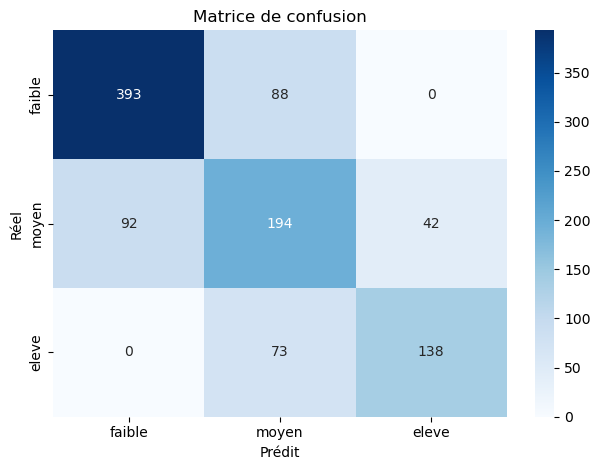

In [15]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['faible','moyen','eleve'],
            yticklabels=['faible','moyen','eleve'])
plt.title('Matrice de confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

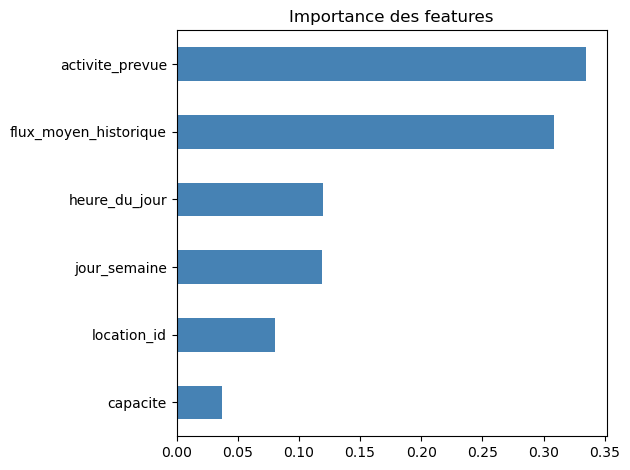

In [16]:
# Importance des features
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', color='steelblue')
plt.title('Importance des features')
plt.tight_layout()
plt.show()

## 9. Test manuel rapide

In [17]:
# Simuler une prédiction comme le ferait l'API
# Exemple : Amphi (id=1), lundi matin 8h, cours prévu, flux moyen historique 80
sample = pd.DataFrame([{
    'location_id': 1,
    'heure_du_jour': 8,
    'jour_semaine': 0,
    'activite_prevue': 1,
    'flux_moyen_historique': 80.0,
    'capacite': 120
}])

pred = model.predict(sample)[0]
proba = model.predict_proba(sample)[0]
label_reverse = {0: 'faible', 1: 'moyen', 2: 'eleve'}

print(f'Prédiction : {label_reverse[pred]}')
print(f'Probabilités — faible: {proba[0]:.2f} | moyen: {proba[1]:.2f} | élevé: {proba[2]:.2f}')

Prédiction : eleve
Probabilités — faible: 0.00 | moyen: 0.31 | élevé: 0.69


## 10. Export model.pkl

In [18]:
# Sauvegarder le modèle ET le mapping des labels
export = {
    'model': model,
    'features': FEATURES,
    'label_map': label_map,
    'label_reverse': label_reverse
}

joblib.dump(export, 'model.pkl')
print('model.pkl exporté ✓')
print('Features attendues par le modèle :', FEATURES)

model.pkl exporté ✓
Features attendues par le modèle : ['location_id', 'heure_du_jour', 'jour_semaine', 'activite_prevue', 'flux_moyen_historique', 'capacite']


In [19]:
# Vérification : recharger et tester
loaded = joblib.load('model.pkl')
pred_check = loaded['model'].predict(sample)[0]
print(f'Vérification après rechargement : {loaded["label_reverse"][pred_check]}')
print('Prêt à livrer à Abdou ✓')

Vérification après rechargement : eleve
Prêt à livrer à Abdou ✓
